# Workflow

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

## Creating Ground Truth

In [2]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create a simple linear straight line as ground truth data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X  + bias

print('First 10 values of X and Y: ')
print(X[:10])
print(y[:10])



First 10 values of X and Y: 
tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


## Separting data into train and test data

In [3]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]



## Visualizing Data

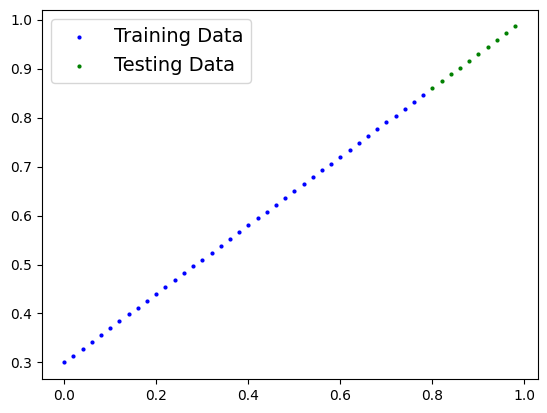

In [4]:
def plot_prediction(train_data=X_train,
                    train_label=y_train,
                    test_data=X_test,
                    test_label=y_test,
                    prediction=None):
    
    plt.scatter(x=train_data, y=train_label, s=4, c='b', label='Training Data')
    plt.scatter(x=test_data, y=test_label, s=4, c='g', label='Testing Data')
    if prediction is not None:
        plt.scatter(x=test_data, y=prediction, s=4, c='r', label='Prediction')
    
    plt.legend(prop={'size': 14})


plot_prediction()

## Build A Linear Regression Model

In [5]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                               requires_grad=True,
                                               dtype=torch.float32))
        
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float32))
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [6]:
# Check the content of the model
MANUAL_SEED = 42
torch.manual_seed(MANUAL_SEED)
model_0 = LinearRegressionModel()

# Method 1
print('Using Parameters')
print(list(model_0.parameters()))

# Method 2
print('\nUsing State Dict')
print(model_0.state_dict())

Using Parameters
[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]

Using State Dict
OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})


## Making Prediction

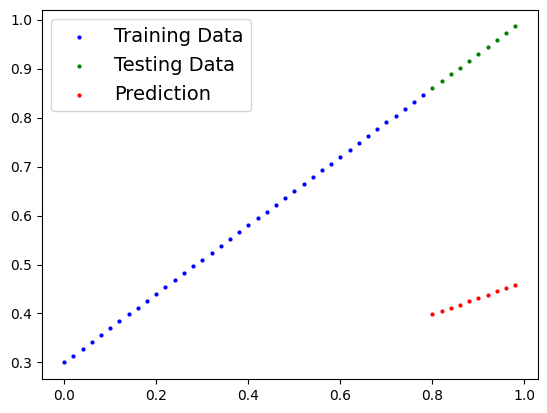

In [7]:
with torch.inference_mode():
    y_preds = model_0(X_test)
    plot_prediction(prediction=y_preds)

## Train the model

In [8]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(model_0.parameters(), lr=1e-2)

# Keep track of losses
plt_epochs = []
plt_train_losses = []
plt_test_losses = []

# Training and Testing Loop
epochs = 5000
for epoch in range(epochs):
    
    """ Training Loop """
    # Forward Pass
    model_0.train()
    y_preds = model_0(X_train)

    # Calculate Loss
    loss = loss_fn(y_preds, y_train)

    # Backward propagation
    optimizer.zero_grad()
    loss.backward()

    # Gradient Descent
    optimizer.step()

    """ Testing Loop """
    model_0.eval()
    with torch.inference_mode():
        test_preds = model_0(X_test)
        test_loss = loss_fn(test_preds, y_test)

    """ Print Results """
    print(f"Epoch: {epoch}")
    print(f"Training Loss: {round(loss.item(),4)} | Testing Loss: {round(test_loss.item(),4)}")

    if epoch % 100 == 0:
        plt_epochs.append(epoch)
        plt_train_losses.append(loss.item())
        plt_test_losses.append(test_loss.item())
    

Epoch: 0
Training Loss: 0.3129 | Testing Loss: 0.4811
Epoch: 1
Training Loss: 0.3014 | Testing Loss: 0.4676
Epoch: 2
Training Loss: 0.2898 | Testing Loss: 0.4541
Epoch: 3
Training Loss: 0.2783 | Testing Loss: 0.4407
Epoch: 4
Training Loss: 0.2668 | Testing Loss: 0.4272
Epoch: 5
Training Loss: 0.2553 | Testing Loss: 0.4137
Epoch: 6
Training Loss: 0.2438 | Testing Loss: 0.4002
Epoch: 7
Training Loss: 0.2322 | Testing Loss: 0.3868
Epoch: 8
Training Loss: 0.2207 | Testing Loss: 0.3733
Epoch: 9
Training Loss: 0.2092 | Testing Loss: 0.3598
Epoch: 10
Training Loss: 0.1977 | Testing Loss: 0.3464
Epoch: 11
Training Loss: 0.1862 | Testing Loss: 0.3329
Epoch: 12
Training Loss: 0.1746 | Testing Loss: 0.3194
Epoch: 13
Training Loss: 0.1631 | Testing Loss: 0.3059
Epoch: 14
Training Loss: 0.1516 | Testing Loss: 0.2925
Epoch: 15
Training Loss: 0.1401 | Testing Loss: 0.279
Epoch: 16
Training Loss: 0.1285 | Testing Loss: 0.2655
Epoch: 17
Training Loss: 0.117 | Testing Loss: 0.2521
Epoch: 18
Training Los

## Visualize the result

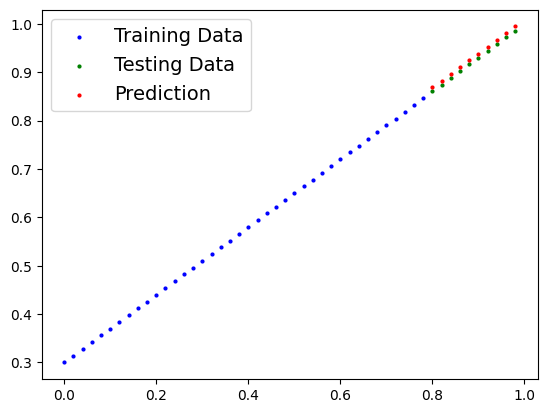

In [9]:
with torch.inference_mode():
    prediction = model_0(X_test)
plot_prediction(prediction=prediction)

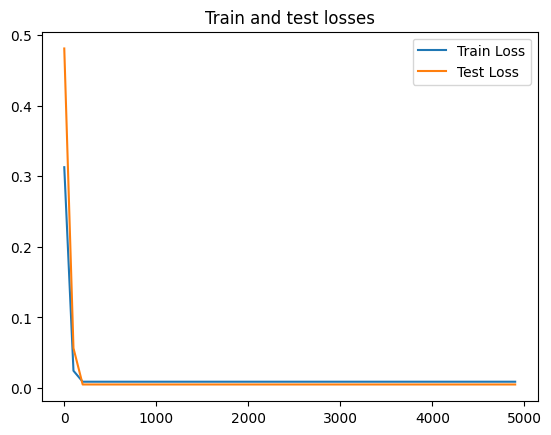

In [10]:
def plot_loss(epochs, train_losses, test_losses):
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, test_losses, label='Test Loss')
    plt.title('Train and test losses')
    plt.legend()

plot_loss(plt_epochs, plt_train_losses, plt_test_losses)

## Save and Loading a Model

In [ ]:
# Save a model
save_folder = Path('models')
save_folder.mkdir(parents=True, exist_ok=True)
save_path = save_folder /'model_0.pt'

torch.save(model_0.state_dict(), save_path)

In [ ]:
# Load a model
loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(save_path, weights_only=True))


OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])